# 01 — Exploratory Data Analysis (EDA)

## 1. Introduction
- Define objective
- Business context

## 2. Data Loading
- Load all CSV files
- Show shape and schema

## 3. Data Cleaning
- Missing values
- Data types
- Outliers

## 4. Univariate Analysis
- Revenue distribution
- Customer behavior
- Product categories

## 5. Bivariate / Multivariate Analysis
- Revenue vs category
- Returns vs size
- Traffic vs conversion

## 6. Visualization
- Time series plots
- Heatmaps
- Bar charts

## 7. Business Insights
- Key findings (bullet points)
- Supported by data

## 8. Summary

Link gemini: https://gemini.google.com/share/c624fa5f088b

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


# DATA LOADING & PREPROCESSING

In [ ]:
def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

In [ ]:
os.listdir(DATA_RAW_PATH)

['customers.csv',
 'geography.csv',
 'inventory.csv',
 'orders.csv',
 'order_items.csv',
 'payments.csv',
 'products.csv',
 'promotions.csv',
 'returns.csv',
 'reviews.csv',
 'sales.csv',
 'sample_submission.csv',
 'shipments.csv',
 'web_traffic.csv']

# EDA KHÁM PHÁ (MỞ RỘNG TỪ CÂU HỎI)

Plan:
1. Phân tích Univariate analysis, Bivariate analysis, Multivariate analysis -> đóng thành một gói khi lặp lại

# I. product.csv

In [ ]:
products_df.head(10)

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.84
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.08,5393.87
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.63,11371.92
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.72,8573.17
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.33,14063.57
5,541,SaigonFlex UC-06,Streetwear,Everyday,M,black,16095.85,15291.06
6,542,SaigonFlex UC-07,Streetwear,Everyday,L,orange,9213.82,6152.07
7,543,SaigonFlex UC-08,Streetwear,Everyday,XL,blue,40.39,22.49
8,544,SaigonFlex UC-09,Streetwear,Everyday,S,white,11334.11,8528.92
9,545,SaigonFlex UC-10,Streetwear,Everyday,M,purple,10045.68,9091.34


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [ ]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'segment', 'size', 'color',
       'price', 'cogs'],
      dtype='object')

In [ ]:
products_df.shape

(2412, 8)

## 1. Tổng quan

### 1.1. Phân tích đơn biến

### 1.1.1. Biến số

#### a. Phân phối và outliers

In [ ]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'segment', 'size', 'color',
       'price', 'cogs'],
      dtype='object')

Đã lưu biểu đồ phân phối tại: images/distribution_plot.png


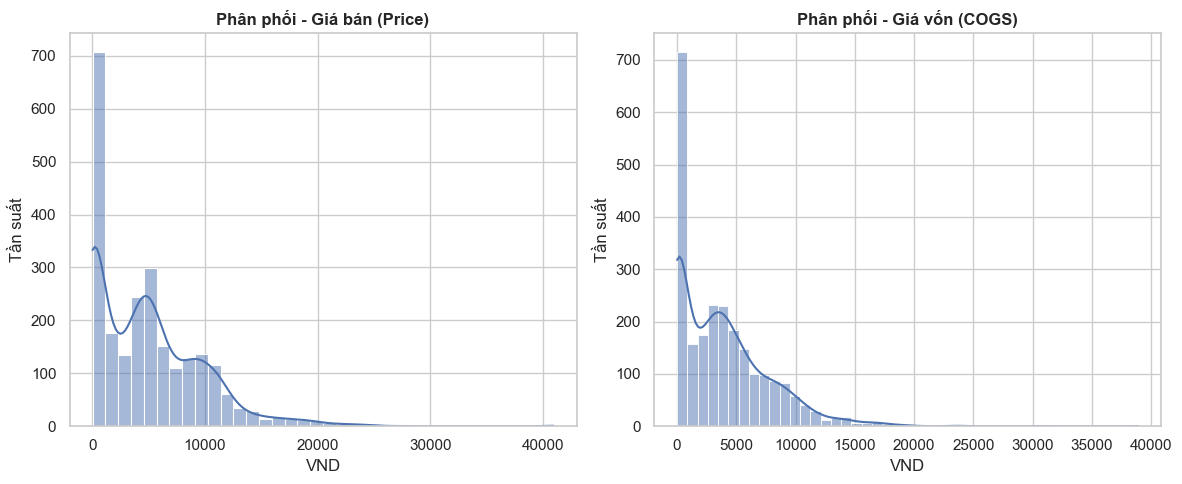

Đã lưu biểu đồ kết hợp tại: images/distribution_boxplot.png


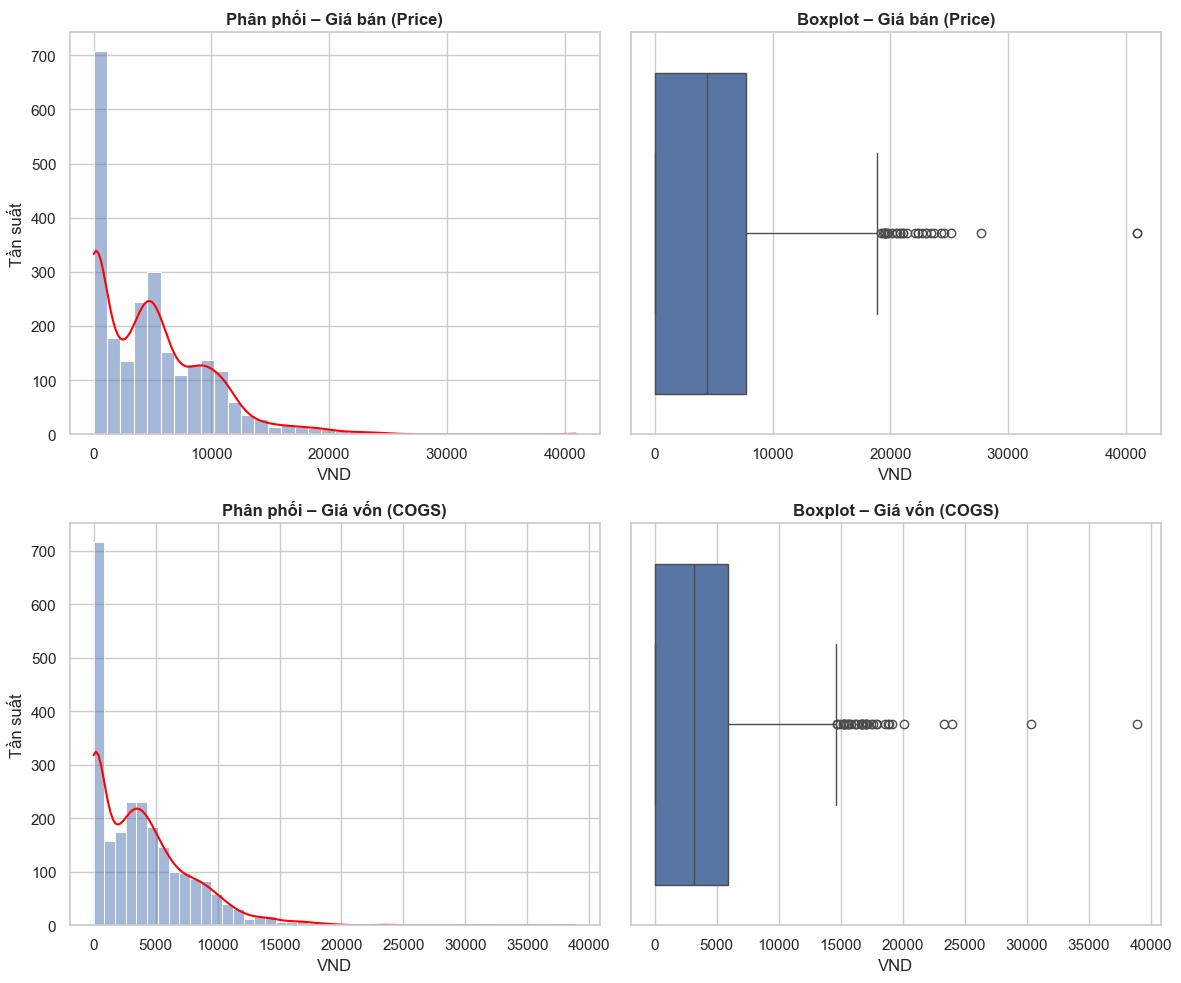

In [ ]:
col_config = {
    'price': {'title': 'Giá bán (Price)', 'xlabel': 'VND'},
    'cogs':  {'title': 'Giá vốn (COGS)',  'xlabel': 'VND'}
}

# Danh sách các cột cần vẽ
con_cols_names = ['price', 'cogs']

# Hàm vẽ biểu đồ phân phối (Histogram + KDE) có tính năng lưu ảnh
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid)
    cols = 2  # Chỉnh thành 2 vì chúng ta chỉ có 2 cột số chính
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(6 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# Hàm vẽ kết hợp Distribution và Boxplot có tính năng lưu ảnh
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ kết hợp tại: {save_path}")
        
    plt.show()

if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu (hỗ trợ .png, .jpg, .pdf...)
# plot_distribution(products_df, con_cols_names, save_path='images/distribution_plot.png')
plot_distribution_boxplot(products_df, con_cols_names, save_path='images/distribution_boxplot.png')

Nhận xét:

- Quan sát:
  - Phân phối: Cả 2 biến số là Giá bán (Price) và Giá vốn (COGS) đều có phân phối lệch phải (right-skewed) khá mạnh, phần lớn dữ liệu tập trung ở vùng giá trị thấp, trong khi phần đuôi kéo dài về phía các giá trị rất cao.
  - Box plot: Nhìn chung lượng outliers khá nhiều ở cả hai biến, đặc biệt xuất hiện nhiều điểm nằm ngoài whisker bên phải.
  - Chi tiết:
    - Giá bán (Price): Dữ liệu tập trung chủ yếu ở vùng giá thấp đến trung bình, với một đỉnh lớn gần vùng giá rất thấp và thêm một cụm mật độ nữa quanh khoảng vài nghìn VND. Phần đuôi phải kéo dài rất xa, xuất hiện nhiều outliers và có điểm cực trị lên tới khoảng 40,000 VND.
    - Giá vốn (COGS): Phân phối có hình dạng tương tự Giá bán, cũng lệch phải rõ rệt và tập trung phần lớn ở vùng thấp. Mật độ cao nhất nằm ở nhóm giá vốn thấp, sau đó giảm dần nhưng vẫn có đuôi dài và nhiều outliers kéo tới gần 39,000 VND.

- Insights:
  - Dữ liệu sản phẩm chủ yếu nằm ở nhóm giá thấp và trung bình, trong khi chỉ có một số ít sản phẩm thuộc nhóm giá rất cao.
  - Phân phối của Giá bán và Giá vốn có hình dạng khá tương đồng, cho thấy hai biến này biến động cùng cấu trúc và có quan hệ khá chặt chẽ về mặt mức giá.
  - Sự xuất hiện của nhiều outliers ở phía giá trị cao cho thấy tập dữ liệu có thể đang trộn lẫn nhiều phân khúc sản phẩm khác nhau, từ nhóm phổ thông đến nhóm cao cấp.
  - Cần xem xét riêng các điểm giá trị rất cao vì chúng có thể đại diện cho các dòng sản phẩm đặc biệt hoặc làm ảnh hưởng mạnh đến các thống kê trung bình và mô hình hóa sau này.


#### b. Thống kê mô tả

In [ ]:
nums_cols = ['price', 'cogs']
products_df[nums_cols].describe()

,price,cogs
count,2412.00,2412.00
mean,4928.22,3868.35
std,4776.74,3878.58
min,9.06,5.18
25%,59.44,35.07
50%,4399.60,3184.93
75%,7720.51,5864.92
max,40950.00,38902.50


### 1.1.2. Biến phân loại (Categorical)

In [ ]:
COL_INFO = {
    'category': {'name': 'Danh mục', 'unit': 'Loại'},
    'segment': {'name': 'Phân khúc', 'unit': 'Nhóm'},
    'size': {'name': 'Kích cỡ', 'unit': 'Size'},
    'color': {'name': 'Màu sắc', 'unit': 'Màu'}
}

# 2. Hàm vẽ biểu đồ phân bố Categorical (Bar chart ngang)
def plot_horizontal_bar_chart(df, cate_cols_names):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    # Thiết lập kích thước: Tăng chiều ngang để có không gian cho số liệu
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows)) 
    axes = axes.flatten()

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]
        
        if col_name in df.columns:
            # Lấy tần suất xuất hiện
            val_counts = df[col_name].value_counts()
            
            # Xử lý: Lấy top 9, nhóm phần còn lại thành 'Khác'
            if len(val_counts) > 10:
                top9 = val_counts.iloc[:9]
                other_sum = val_counts.iloc[9:].sum()
                plot_data = pd.concat([top9, pd.Series({'Khác': other_sum})])
            else:
                plot_data = val_counts
                
            # Đảm bảo index là kiểu chuỗi
            plot_data.index = plot_data.index.astype(str)
            
            # Vẽ Bar chart ngang (Thêm palette cho sinh động)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)
            
            # Lấy thông tin Tên và Đơn vị từ Từ điển
            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'Loại'}) 
            
            # Cài đặt tiêu đề và nhãn
            ax.set_title(f"Phân bố - {info['name']}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Số lượng", fontsize=12)
            ax.set_ylabel(f"{info['name']} ({info['unit']})", fontsize=12)
            
            # Thêm con số thực tế bên phải mỗi thanh bar
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f'{int(width)}', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=11, 
                                xytext=(5, 0), textcoords='offset points')
            
            # Mở rộng giới hạn trục x thêm 15% để số liệu (annotate) không bị che khuất
            ax.set_xlim(0, max(plot_data.values) * 1.15)
            
        else:
            ax.set_visible(False)
            
    # Ẩn các trục không sử dụng nếu số lượng cột là số lẻ
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

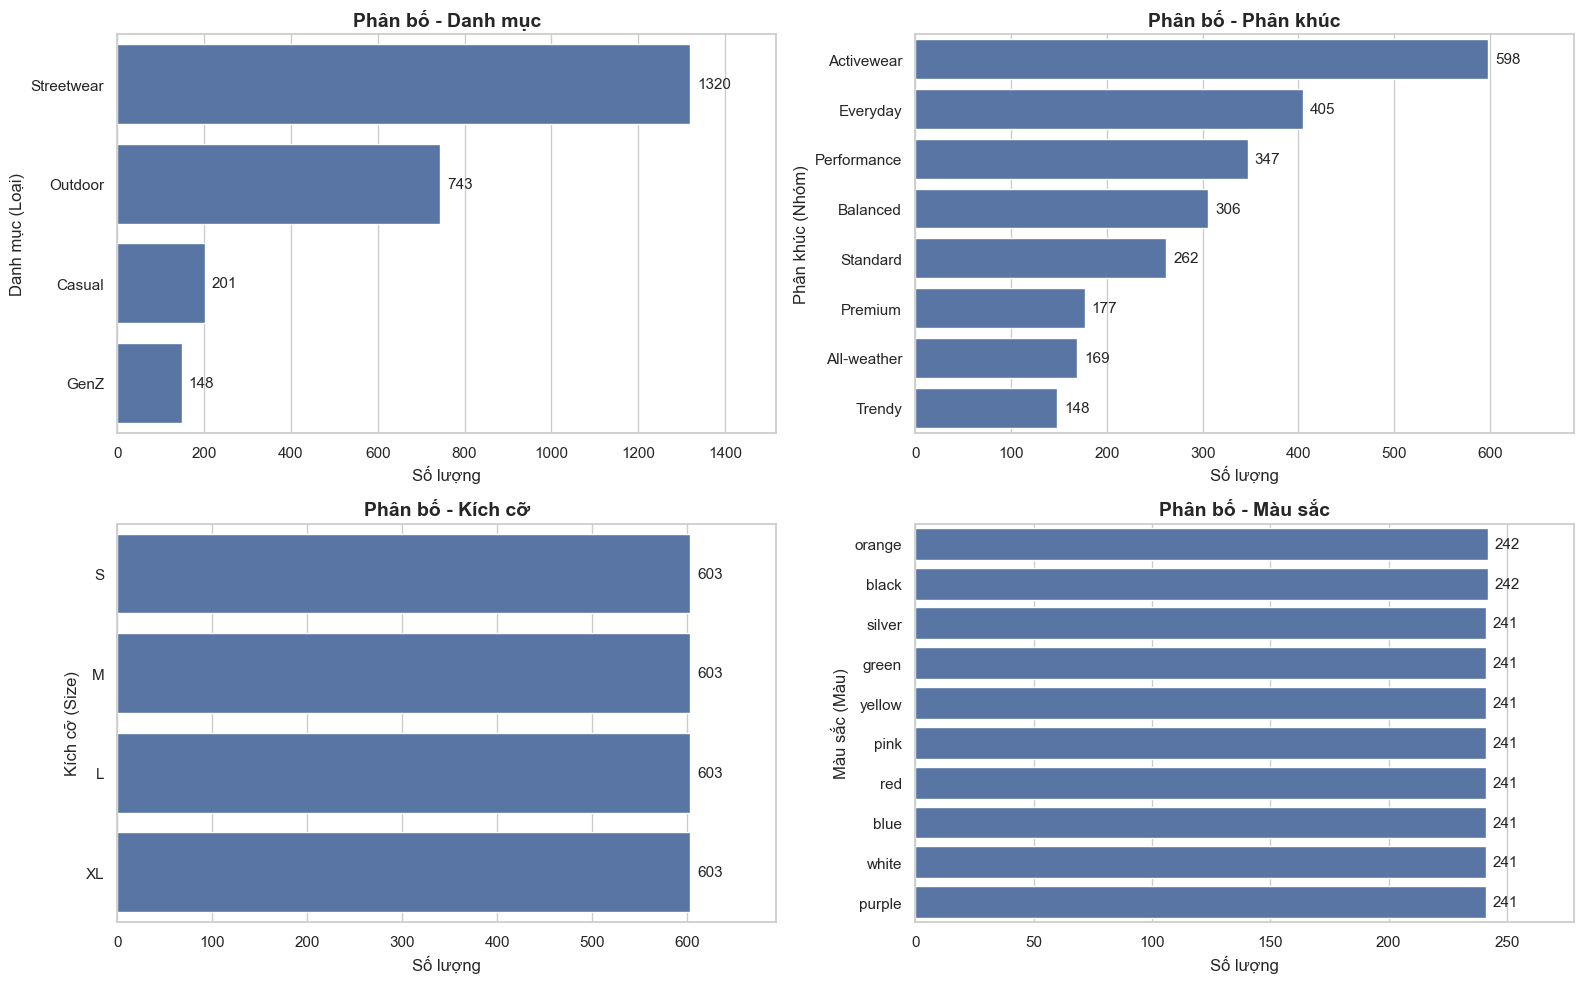

In [ ]:
cate_cols = ['category', 'segment', 'size', 'color']
plot_horizontal_bar_chart(products_df, cate_cols)

Nhận xét:

- Quan sát:
  - Danh mục: Phân bố không đồng đều, Streetwear chiếm nhiều nhất với 1320 sản phẩm (~54.7%), tiếp theo là Outdoor với 743 sản phẩm (~30.8%). Casual (201, ~8.3%) và GenZ (148, ~6.1%) chiếm tỷ trọng khá nhỏ.
  - Phân khúc: Activewear dẫn đầu với 598 sản phẩm (~24.8%), sau đó là Everyday (405, ~16.8%), Performance (347, ~14.4%), Balanced (306, ~12.7%) và Standard (262, ~10.9%). Premium, All-weather và Trendy là các nhóm có quy mô thấp nhất.
  - Kích cỡ: 4 size S, M, L, XL có phân bố đồng đều tuyệt đối, mỗi size đều có 603 sản phẩm (25%).
  - Màu sắc: 10 màu có phân bố gần như tuyệt đối đồng đều. Orange và black có 242 sản phẩm, các màu còn lại đều ở mức 241 sản phẩm.

- Insights:
  - Danh mục sản phẩm đang tập trung mạnh vào Streetwear và Outdoor, cho thấy định hướng chính của catalog nghiêng về thời trang năng động, ứng dụng hằng ngày và ngoài trời.
  - Casual và GenZ có tỷ trọng khá thấp, nên khi phân tích sâu theo 2 nhóm này cần lưu ý cỡ mẫu nhỏ hơn, dễ làm kết quả dao động hơn các nhóm lớn.
  - Cơ cấu phân khúc đa dạng hơn danh mục, nhưng Activewear vẫn là nhóm nổi bật nhất; đây có thể là phân khúc trọng tâm cần ưu tiên theo dõi về doanh thu, tồn kho hoặc hiệu quả khuyến mãi.
  - Phân bố size đồng đều tuyệt đối cho thấy danh mục được chuẩn hóa rất rõ theo kích cỡ, thuận lợi cho phân tích so sánh giữa các size vì ít bị lệch mẫu.
  - Phân bố màu sắc gần như bằng nhau cho thấy catalog được xây dựng cân bằng giữa các màu, vì vậy từ biểu đồ này chưa thể kết luận màu nào được ưa chuộng hơn, mà chỉ phản ánh cơ cấu danh mục hiện có.
  - Nếu dùng category hoặc segment trong mô hình phân tích/dự báo, cần lưu ý hiện tượng mất cân bằng nhóm ở category và một phần ở segment để tránh bias khi diễn giải kết quả.


## 2. Tiền xử lý

In [ ]:
# Tách tên sản phẩm (product_name) thành 'brand' và 'product_code'
products_df[['brand', 'product_code']] = products_df['product_name'].str.split(' ', n=1, expand=True)
cols = ['product_id', 'product_name', 'brand', 'product_code', 'category', 'segment', 'size', 'color', 'price', 'cogs']
products_df = products_df[cols]

# Định nghĩa hàm quy đổi tiền tệ về đơn vị chung là "Đồng" (VND)
def standardize_currency(value):
    # Lấy mốc 100 làm ngưỡng phân định
    if value < 100:
        return value * 1000  # Đang là ngàn đồng -> Nhân 1000 ra đồng
    else:
        return value         # Đang là đồng -> Giữ nguyên

# Áp dụng quy đổi cho 2 cột giá bán (price) và giá vốn (cogs)
products_df['price'] = products_df['price'].apply(standardize_currency)
products_df['cogs'] = products_df['cogs'].apply(standardize_currency)

# Làm tròn thành số nguyên (bỏ số thập phân thừa)
products_df['price'] = products_df['price'].round(0).astype(int)
products_df['cogs'] = products_df['cogs'].round(0).astype(int)

# Lưu file dữ liệu sạch
products_df.to_csv(os.path.join(PROCESSED_PATH, 'products_cleaned_final.csv'), index=False)

## 3. Phân tích câu hỏi 

### Câu hỏi 2: Phân khúc sản phẩm (segment) nào trong products.csv có tỷ suất lợi nhuận gộp trung bình cao nhất, với công thức (price − cogs)/price?

Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất là 'All-weather' với 28.42%.

Đã lưu biểu đồ tỷ suất lợi nhuận tại: images/segment_gross_margin.png


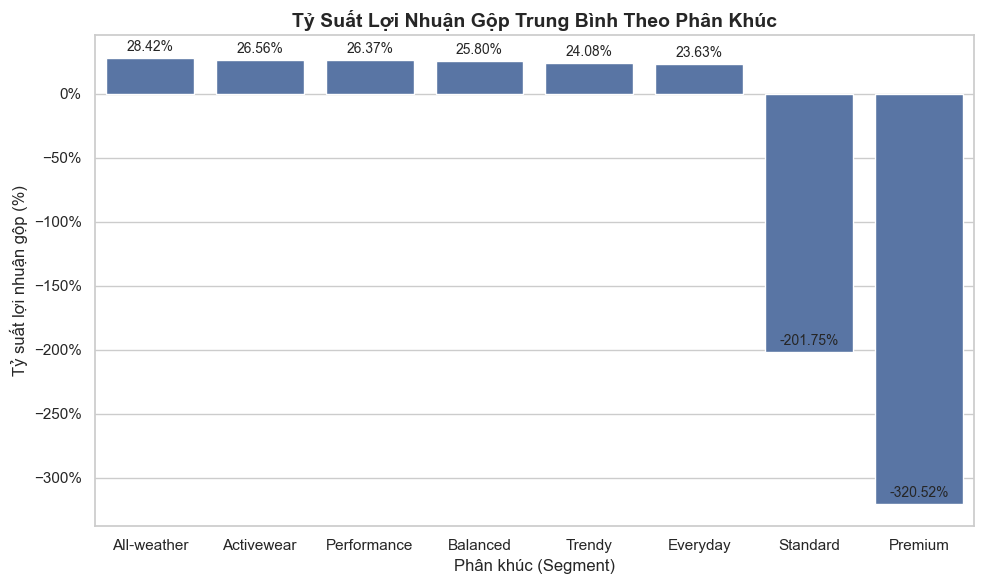

In [ ]:
import matplotlib.ticker as mtick
# 1. Tạo cột Tỷ suất lợi nhuận gộp (Gross Margin)
ques_products_df = pd.read_csv(os.path.join(PROCESSED_PATH, 'products_cleaned_final.csv'))
ques_products_df['gross_margin'] = (ques_products_df['price'] - ques_products_df['cogs']) / ques_products_df['price']

# 2. Tính trung bình tỷ suất lợi nhuận theo phân khúc và sắp xếp giảm dần
segment_margins = ques_products_df.groupby('segment')['gross_margin'].mean().sort_values(ascending=False).reset_index()

# In ra console phân khúc cao nhất
highest_segment = segment_margins.iloc[0]['segment']
highest_margin = segment_margins.iloc[0]['gross_margin']
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất là '{highest_segment}' với {highest_margin:.2%}.\n")

# Hàm vẽ biểu đồ cột so sánh tỷ suất lợi nhuận có tính năng lưu ảnh
def plot_margin_by_segment(data, save_path=None):
    plt.figure(figsize=(10, 6))
    
    # Sử dụng seaborn để vẽ barplot
    ax = sns.barplot(x='segment', y='gross_margin', data=data)
    
    # Tùy chỉnh tiêu đề và nhãn
    plt.title('Tỷ Suất Lợi Nhuận Gộp Trung Bình Theo Phân Khúc', fontweight='bold', fontsize=14)
    plt.xlabel('Phân khúc (Segment)', fontsize=12)
    plt.ylabel('Tỷ suất lợi nhuận gộp (%)', fontsize=12)
    
    # Định dạng trục y hiển thị theo phần trăm (%)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Thêm giá trị text trên đỉnh mỗi cột
    for p in ax.patches:
        margin_value = p.get_height()
        ax.annotate(f'{margin_value:.2%}', 
                    (p.get_x() + p.get_width() / 2., margin_value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()

    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tỷ suất lợi nhuận tại: {save_path}")

    plt.show()

# Tạo thư mục images nếu chưa tồn tại
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu (hỗ trợ .png, .jpg, .pdf...)
plot_margin_by_segment(segment_margins, save_path='images/segment_gross_margin.png')

Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất là 'Standard' với 31.34%.

Đã lưu biểu đồ tỷ suất lợi nhuận tại: images/segment_gross_margin.png


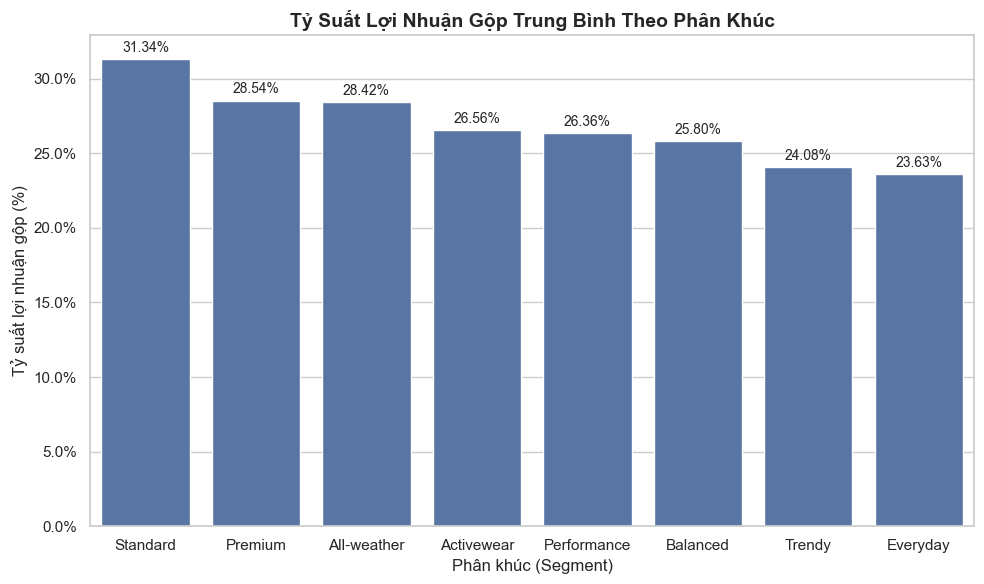

In [ ]:
import matplotlib.ticker as mtick
# 1. Tạo cột Tỷ suất lợi nhuận gộp (Gross Margin)
ques_products_df = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
ques_products_df['gross_margin'] = (ques_products_df['price'] - ques_products_df['cogs']) / ques_products_df['price']

# 2. Tính trung bình tỷ suất lợi nhuận theo phân khúc và sắp xếp giảm dần
segment_margins = ques_products_df.groupby('segment')['gross_margin'].mean().sort_values(ascending=False).reset_index()

# In ra console phân khúc cao nhất
highest_segment = segment_margins.iloc[0]['segment']
highest_margin = segment_margins.iloc[0]['gross_margin']
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất là '{highest_segment}' với {highest_margin:.2%}.\n")

# Hàm vẽ biểu đồ cột so sánh tỷ suất lợi nhuận có tính năng lưu ảnh
def plot_margin_by_segment(data, save_path=None):
    plt.figure(figsize=(10, 6))
    
    # Sử dụng seaborn để vẽ barplot
    ax = sns.barplot(x='segment', y='gross_margin', data=data)
    
    # Tùy chỉnh tiêu đề và nhãn
    plt.title('Tỷ Suất Lợi Nhuận Gộp Trung Bình Theo Phân Khúc', fontweight='bold', fontsize=14)
    plt.xlabel('Phân khúc (Segment)', fontsize=12)
    plt.ylabel('Tỷ suất lợi nhuận gộp (%)', fontsize=12)
    
    # Định dạng trục y hiển thị theo phần trăm (%)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Thêm giá trị text trên đỉnh mỗi cột
    for p in ax.patches:
        margin_value = p.get_height()
        ax.annotate(f'{margin_value:.2%}', 
                    (p.get_x() + p.get_width() / 2., margin_value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()

    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tỷ suất lợi nhuận tại: {save_path}")

    plt.show()

# Tạo thư mục images nếu chưa tồn tại
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu (hỗ trợ .png, .jpg, .pdf...)
plot_margin_by_segment(segment_margins, save_path='images/segment_gross_margin.png')

# II. customers.csv

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

### 1.2.3. Phân tích thời gian

# III. promotions.csv

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# IV. geography.csv

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# V. orders.csv — Đơn hàng

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# VI. order_items.csv — Chi tiết đơn hàng

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# VII. payments.csv — Thanh toán

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# VIII. shipments.csv — Vận chuyển

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# IX. returns.csv — Trả hàng

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# X. reviews.csv — Đánh giá

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# XI. sales.csv — Dữ liệu doanh thu

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# XII. inventory.csv — Tồn kho

## 1. Tổng quan

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

# XIII. web_traffic.csv

## 1. Tổng quan

In [ ]:
web_traffic_df.head(10)

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search
2,2013-01-03,10076,7458,36963,0.00,263.60,direct
3,2013-01-04,9973,8063,53078,0.01,151.80,direct
4,2013-01-05,10223,7882,36790,0.01,168.60,referral
5,2013-01-06,9545,6992,47160,0.00,263.60,social_media
6,2013-01-07,10203,7354,32749,0.00,252.10,organic_search
7,2013-01-08,9456,7459,31482,0.00,192.40,paid_search
8,2013-01-09,9162,7108,46717,0.00,312.80,organic_search
9,2013-01-10,9887,7878,38472,0.01,285.40,organic_search


In [ ]:
web_traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[ns]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 199.8+ KB


In [ ]:
web_traffic_df.columns

Index(['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate',
       'avg_session_duration_sec', 'traffic_source'],
      dtype='object')

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

Đã lưu biểu đồ phân phối tại: images\web_distribution_plot.png


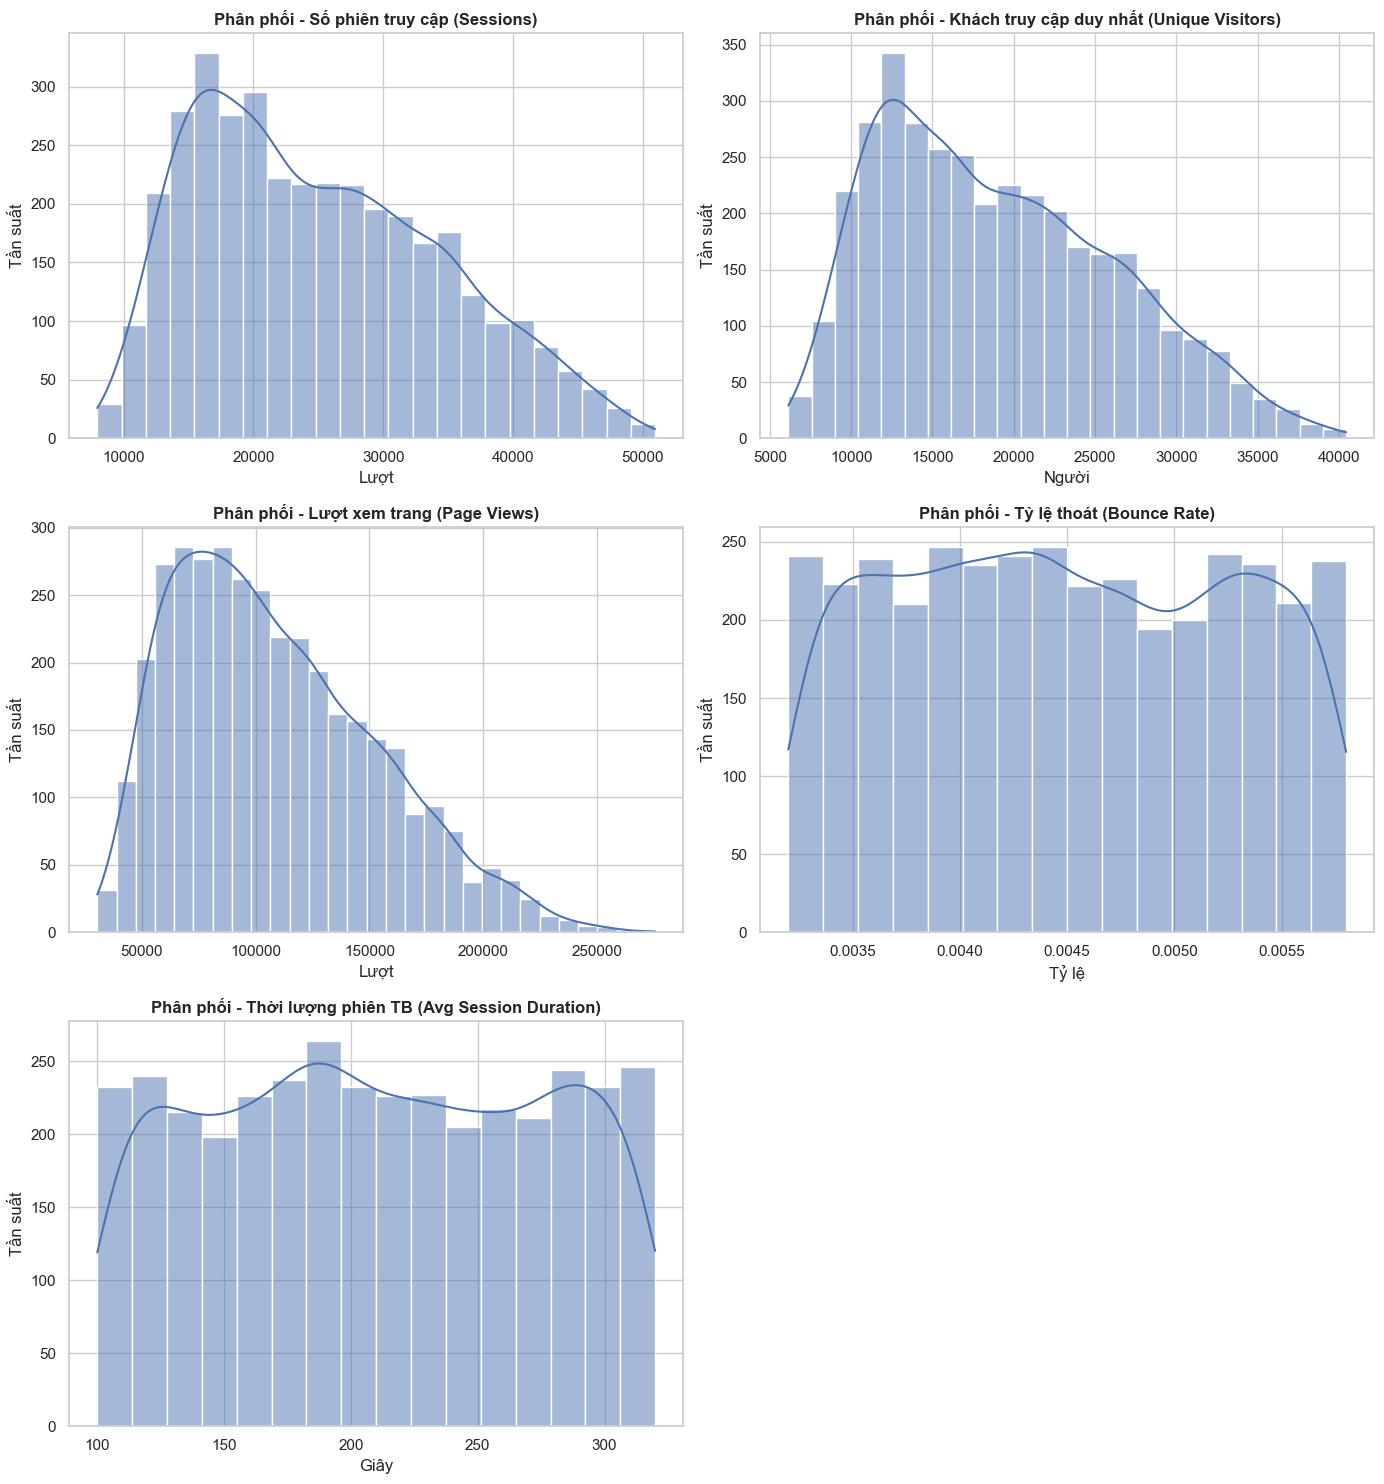

Đã lưu biểu đồ kết hợp tại: images\web_distribution_boxplot.png


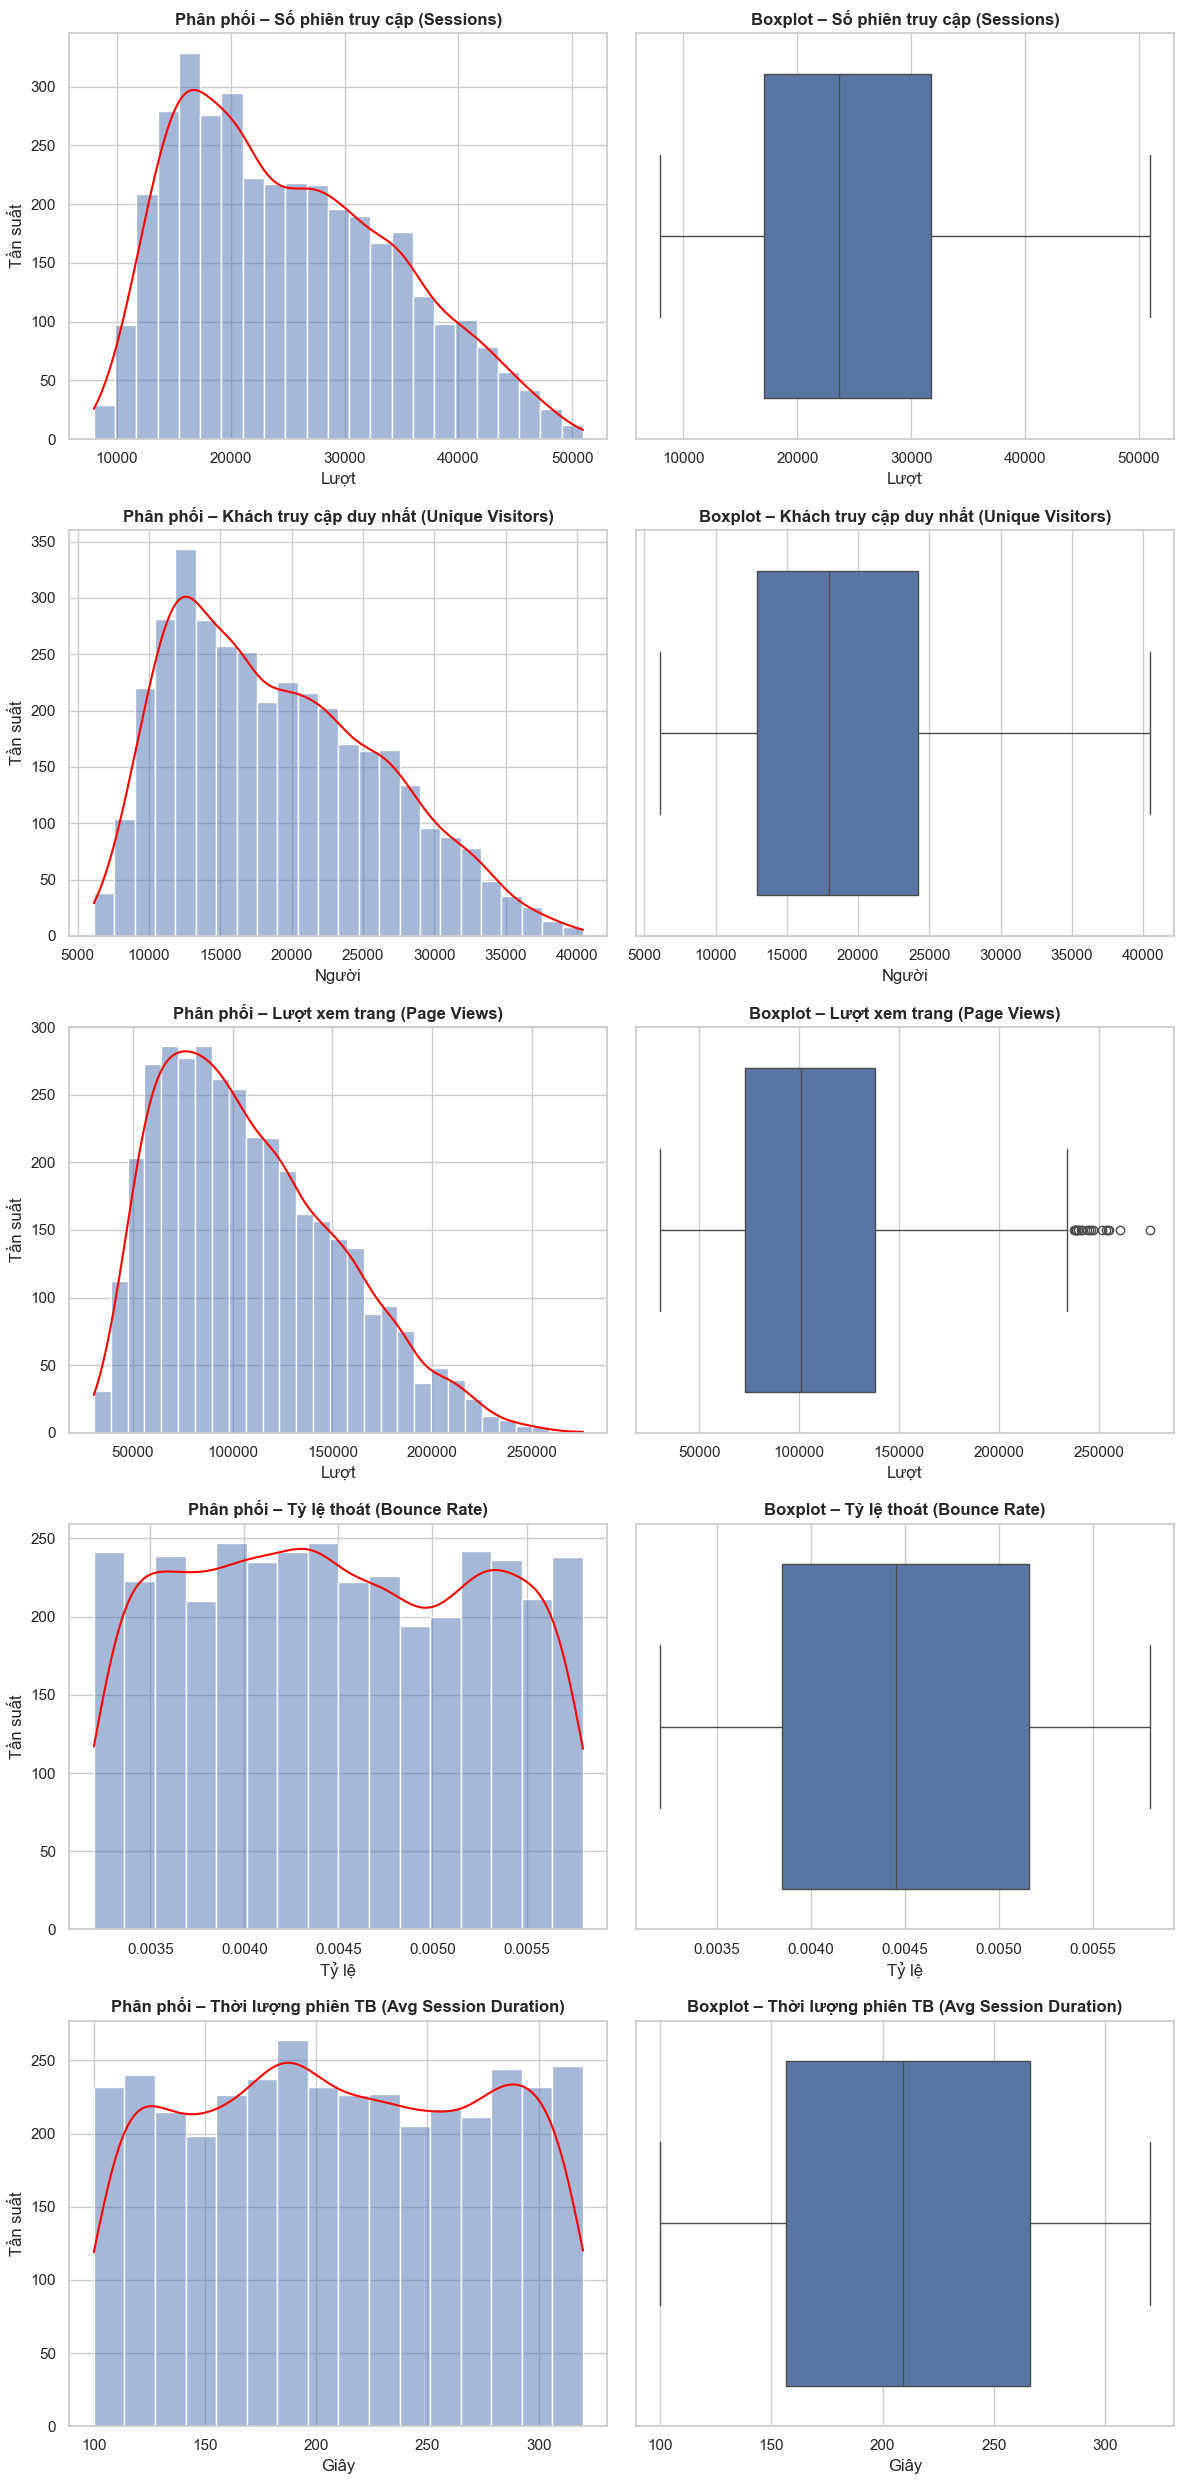

In [ ]:
# 2. Cấu hình tiêu đề và nhãn trục X cho các cột số trong web_traffic.csv
col_config = {
    'sessions': {'title': 'Số phiên truy cập (Sessions)', 'xlabel': 'Lượt'},
    'unique_visitors': {'title': 'Khách truy cập duy nhất (Unique Visitors)', 'xlabel': 'Người'},
    'page_views': {'title': 'Lượt xem trang (Page Views)', 'xlabel': 'Lượt'},
    'bounce_rate': {'title': 'Tỷ lệ thoát (Bounce Rate)', 'xlabel': 'Tỷ lệ'},
    'avg_session_duration_sec': {'title': 'Thời lượng phiên TB (Avg Session Duration)', 'xlabel': 'Giây'}
}

# Danh sách các cột định lượng cần vẽ
con_cols_names = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']

# Hàm vẽ biểu đồ phân phối (Histogram + KDE) có tính năng lưu ảnh
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid)
    cols = 2  # Đặt 2 biểu đồ trên mỗi hàng cho dễ nhìn
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(7 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# Hàm vẽ kết hợp Distribution và Boxplot có tính năng lưu ảnh
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        # Kiểm tra an toàn trước khi đổi màu đường KDE (phòng trường hợp data lỗi không sinh ra KDE)
        if len(ax.lines) > 0:
            ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ kết hợp tại: {save_path}")
        
    plt.show()

# 3. Tạo thư mục và gọi hàm
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu
plot_distribution(web_traffic_df, con_cols_names, save_path=os.path.join('images', 'web_distribution_plot.png'))
plot_distribution_boxplot(web_traffic_df, con_cols_names, save_path=os.path.join('images', 'web_distribution_boxplot.png'))

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

### 1.2.3. Phân tích thời gian

## 2. Tiền xử lý

## 3. Phân tích câu hỏi 

### Câu hỏi: Trong web_traffic.csv, nguồn truy cập (traffic_source) nào có tỷ lệ thoát trung bình (bounce_rate) thấp nhất trên tất cả các ngày xuất hiện nguồn đó trong cột traffic_source?

In [ ]:
web_traffic_df.columns

Index(['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate',
       'avg_session_duration_sec', 'traffic_source'],
      dtype='object')

Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất là 'email_campaign' với 0.4458%.

Đã lưu biểu đồ tỷ lệ thoát tại: images/avg_bounce_rate_by_source.png


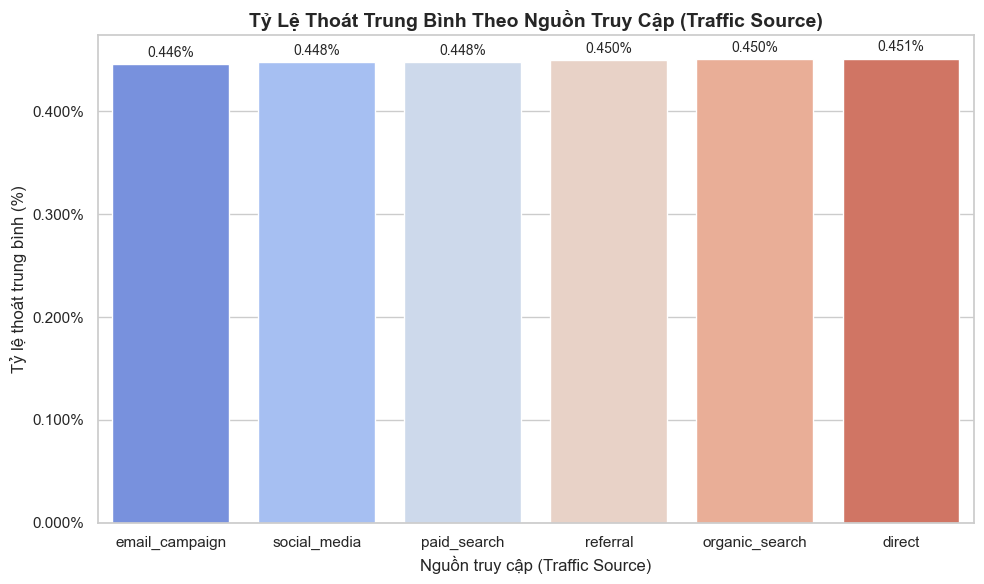

In [ ]:
bounce_rate_by_source = web_traffic_df.groupby('traffic_source')['bounce_rate'].mean().sort_values(ascending=True).reset_index()

# In ra kết quả
lowest_source = bounce_rate_by_source.iloc[0]['traffic_source']
lowest_rate = bounce_rate_by_source.iloc[0]['bounce_rate']
print(f"Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất là '{lowest_source}' với {lowest_rate:.4%}.\n")

# Hàm vẽ biểu đồ thanh so sánh tỷ lệ thoát có tính năng lưu ảnh
def plot_avg_bounce_rate(data, save_path=None):
    plt.figure(figsize=(10, 6))
    
    # Vẽ barplot với seaborn
    ax = sns.barplot(x='traffic_source', y='bounce_rate', data=data, palette='coolwarm')
    
    # Tùy chỉnh tiêu đề và nhãn
    plt.title('Tỷ Lệ Thoát Trung Bình Theo Nguồn Truy Cập (Traffic Source)', fontweight='bold', fontsize=14)
    plt.xlabel('Nguồn truy cập (Traffic Source)', fontsize=12)
    plt.ylabel('Tỷ lệ thoát trung bình (%)', fontsize=12)
    
    # Định dạng trục y hiển thị theo phần trăm (%)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Thêm giá trị text trên đỉnh mỗi cột
    for p in ax.patches:
        rate_value = p.get_height()
        ax.annotate(f'{rate_value:.3%}', 
                    (p.get_x() + p.get_width() / 2., rate_value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()

    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tỷ lệ thoát tại: {save_path}")

    plt.show()

# Tạo thư mục images nếu chưa tồn tại
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu (hỗ trợ .png, .jpg, .pdf...)
plot_avg_bounce_rate(bounce_rate_by_source, save_path='images/avg_bounce_rate_by_source.png')

### Câu hỏi: Trong customers.csv, xét các khách hàng có age_group khác null, nhóm tuổi nào có số đơn hàng trung bình trên mỗi khách hàng cao nhất? (tổng số đơn / số khách hàng trong nhóm)

Đã lưu biểu đồ tại: images/avg_orders_by_age.png


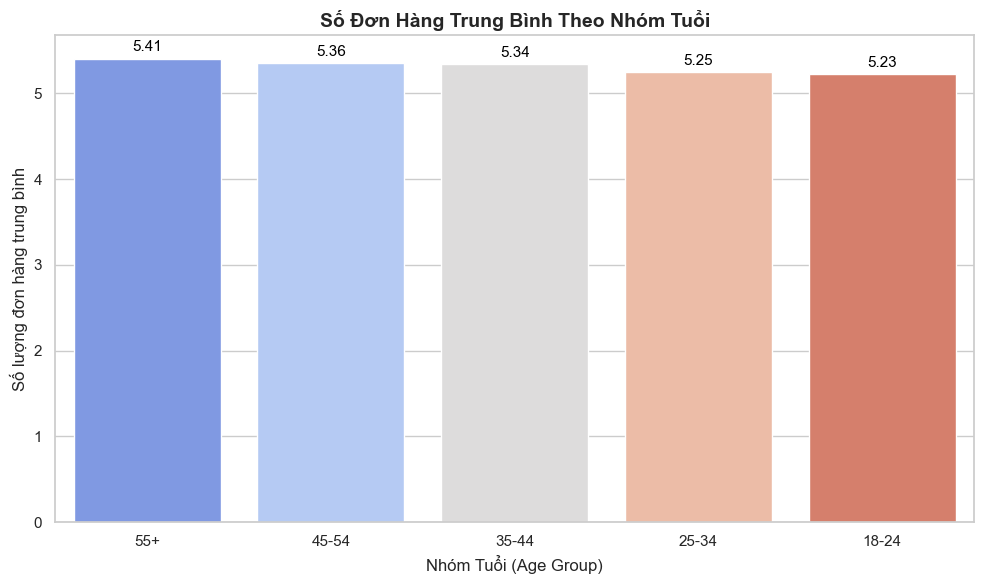

--------------------------------------------------
Kết luận: Nhóm tuổi có số đơn hàng trung bình cao nhất là '55+' với 5.41 đơn/khách hàng.


In [ ]:
customers_df = customers_df.dropna(subset=['age_group'])

# Đếm số lượng đơn hàng của mỗi khách hàng
order_counts = orders_df['customer_id'].value_counts().reset_index()
order_counts.columns = ['customer_id', 'order_count']

# Kết hợp bảng khách hàng với số lượng đơn hàng
merged_df = customers_df.merge(order_counts, on='customer_id', how='left')
# Điền 0 cho những khách hàng chưa có đơn hàng nào
merged_df['order_count'] = merged_df['order_count'].fillna(0) 

# 3. Tính toán theo nhóm tuổi
age_group_stats = merged_df.groupby('age_group').agg(
    total_orders=('order_count', 'sum'),
    total_customers=('customer_id', 'count')
).reset_index()

# Tính số đơn hàng trung bình / khách hàng
age_group_stats['avg_orders'] = age_group_stats['total_orders'] / age_group_stats['total_customers']

# Sắp xếp để biểu đồ đẹp hơn (theo thứ tự giảm dần của avg_orders)
age_group_stats = age_group_stats.sort_values(by='avg_orders', ascending=False)

# Cấu hình biểu đồ
col_config = {
    'avg_orders': {
        'title': 'Số Đơn Hàng Trung Bình Theo Nhóm Tuổi', 
        'xlabel': 'Nhóm Tuổi (Age Group)', 
        'ylabel': 'Số lượng đơn hàng trung bình'
    }
}

# Hàm vẽ biểu đồ cột có tính năng lưu ảnh
def plot_avg_orders_by_age(df, save_path=None):
    plt.figure(figsize=(10, 6))
    
    cfg = col_config['avg_orders']
    
    # Vẽ biểu đồ
    ax = sns.barplot(data=df, x='age_group', y='avg_orders', palette='coolwarm')
    
    plt.title(f"{cfg['title']}", fontweight='bold', fontsize=14)
    plt.xlabel(cfg['xlabel'], fontsize=12)
    plt.ylabel(cfg['ylabel'], fontsize=12)
    
    # Gắn nhãn giá trị trên mỗi cột
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', 
                    fontsize=11, color='black', 
                    xytext=(0, 8), textcoords='offset points')
        
    plt.tight_layout()
    
    # Lưu ảnh
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tại: {save_path}")
        
    plt.show()

# Tạo thư mục lưu ảnh
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm vẽ và lưu ảnh
plot_avg_orders_by_age(age_group_stats, save_path='images/avg_orders_by_age.png')

# In kết luận
best_age_group = age_group_stats.iloc[0]['age_group']
max_avg = age_group_stats.iloc[0]['avg_orders']
print("-" * 50)
print(f"Kết luận: Nhóm tuổi có số đơn hàng trung bình cao nhất là '{best_age_group}' với {max_avg:.2f} đơn/khách hàng.")

### Câu hỏi: Trong các đơn hàng có order_status = ’cancelled’ trong orders.csv, phương thức thanh toán nào được sử dụng nhiều nhất?

Đã lưu biểu đồ phân phối tại: images/cancelled_payment_methods.png


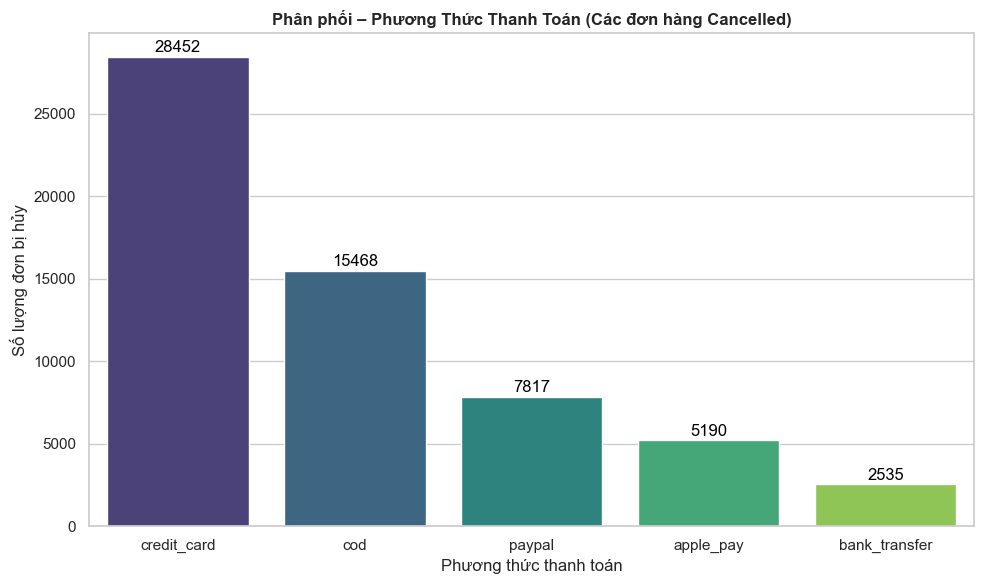


=> Kết luận: Phương thức thanh toán được sử dụng nhiều nhất là 'credit_card' với 28452 đơn hàng.


In [ ]:
# 2. Lọc các đơn hàng bị hủy
cancelled_orders = orders_df[orders_df['order_status'] == 'cancelled']

# 3. Thống kê số lượng từng phương thức thanh toán
payment_counts = cancelled_orders['payment_method'].value_counts().reset_index()
payment_counts.columns = ['payment_method', 'count']

# Cấu hình biểu đồ
col_config = {
    'payment_method': {
        'title': 'Phương Thức Thanh Toán (Các đơn hàng Cancelled)', 
        'xlabel': 'Phương thức thanh toán', 
        'ylabel': 'Số lượng đơn bị hủy'
    }
}

# Hàm vẽ biểu đồ cột có tính năng lưu ảnh
def plot_cancelled_payment_methods(df, save_path=None):
    plt.figure(figsize=(10, 6))
    
    cfg = col_config['payment_method']
    
    # Vẽ biểu đồ barplot
    sns.barplot(data=df, x='payment_method', y='count', palette='viridis')
    
    plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
    plt.xlabel(cfg['xlabel'])
    plt.ylabel(cfg['ylabel'])
    
    # Gắn nhãn số lượng trên đỉnh mỗi cột để dễ quan sát
    for index, row in df.iterrows():
        plt.text(index, row['count'] + (df['count'].max() * 0.01), 
                 str(row['count']), color='black', ha="center")
        
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# Tạo thư mục lưu ảnh
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu
plot_cancelled_payment_methods(payment_counts, save_path='images/cancelled_payment_methods.png')

# Kết luận in ra console
most_used_method = payment_counts.iloc[0]['payment_method']
most_used_count = payment_counts.iloc[0]['count']
print(f"\n=> Kết luận: Phương thức thanh toán được sử dụng nhiều nhất là '{most_used_method}' với {most_used_count} đơn hàng.")

### Câu hỏi: Trong payments.csv, kế hoạch trả góp nào có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất?

Đã lưu biểu đồ tại: images/avg_payment_by_installments.png


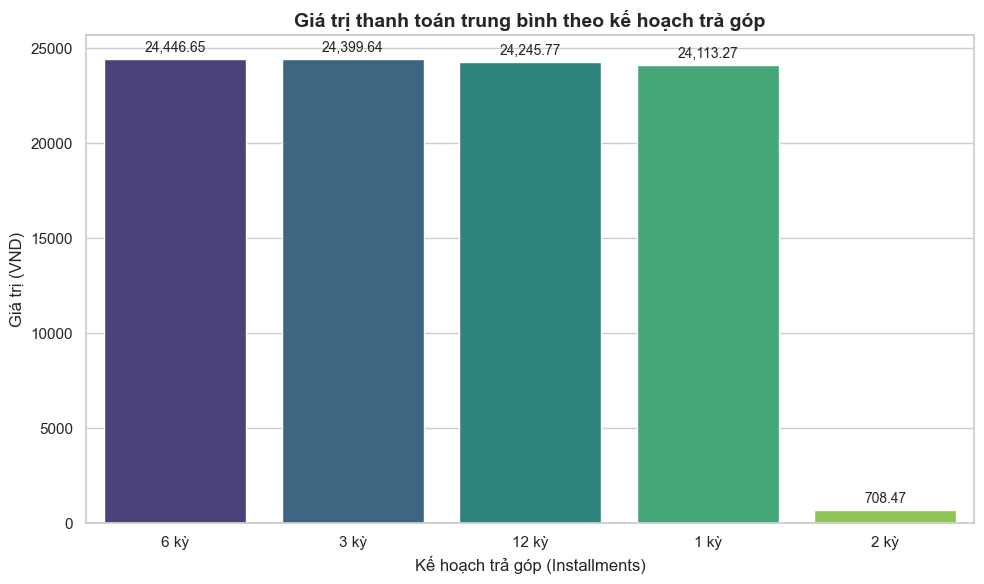

Kế hoạch trả góp có giá trị thanh toán trung bình cao nhất là: 6 kỳ, với giá trị 24,446.65


In [ ]:
# Cấu hình hiển thị cột
col_config = {
    'payment_value': {'title': 'Giá trị thanh toán trung bình', 'ylabel': 'Giá trị (VND)'}
}

# Hàm vẽ biểu đồ thanh so sánh giá trị thanh toán trung bình có tính năng lưu ảnh
def plot_avg_payment_by_installments(df, save_path=None):
    # Tính toán giá trị trung bình theo từng nhóm trả góp
    avg_payment = df.groupby('installments')['payment_value'].mean().reset_index()
    avg_payment = avg_payment.sort_values(by='payment_value', ascending=False)
    
    # Ép kiểu sang chuỗi và thêm hậu tố 'kỳ' để biểu đồ hiển thị dạng phân loại (categorical)
    avg_payment['installments_label'] = avg_payment['installments'].astype(str) + ' kỳ'

    # Khởi tạo khung biểu đồ
    plt.figure(figsize=(10, 6))
    cfg = col_config.get('payment_value')
    
    # Vẽ biểu đồ cột
    ax = sns.barplot(x='installments_label', y='payment_value', data=avg_payment, palette='viridis')
    
    # Tùy chỉnh tiêu đề và nhãn
    plt.title(f"{cfg['title']} theo kế hoạch trả góp", fontweight='bold', fontsize=14)
    plt.xlabel('Kế hoạch trả góp (Installments)', fontsize=12)
    plt.ylabel(cfg['ylabel'], fontsize=12)
    
    # Thêm giá trị text trên đỉnh mỗi cột
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(f'{value:,.2f}', 
                    (p.get_x() + p.get_width() / 2., value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()

    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tại: {save_path}")

    plt.show()

# Đọc dữ liệu từ file payments.csv

# Tạo thư mục images nếu chưa tồn tại
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu (hỗ trợ .png, .jpg, .pdf...)
plot_avg_payment_by_installments(payments_df, save_path='images/avg_payment_by_installments.png')

# In ra kết quả thống kê dạng text
highest_installment = payments_df.groupby('installments')['payment_value'].mean().idxmax()
highest_value = payments_df.groupby('installments')['payment_value'].mean().max()
print(f"Kế hoạch trả góp có giá trị thanh toán trung bình cao nhất là: {highest_installment} kỳ, với giá trị {highest_value:,.2f}")